In [134]:
import pandas as pd
df = pd.read_csv("titanic.csv")

In [135]:
from pandas.api.types import is_numeric_dtype

missing_report = df.isna().mean()*100

print(missing_report[missing_report > 0])

for col, pct in missing_report.items():

    if pct < 5:
        df.dropna(subset=[col], inplace=True)

    elif 5 <= pct <= 30:

        if is_numeric_dtype(df[col]):
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

    else:
        df.drop(columns=col, inplace=True)

age            19.865320
embarked        0.224467
deck           77.216611
embark_town     0.224467
dtype: float64


Part B — Predictive modeling, continuing from the same cleaned data

In [136]:
x = df[["pclass", "sex","age","sibsp","parch","fare","embarked"]]
y = df["survived"]

Columns with less than 5% missing values were handled by removing rows containing missing values because the proportion of missing observations was very small.
Columns with 5-30% missing values were imputed:
- Numeric columns: median
- Categorical columns: mode

Columns with >30% missing values were dropped.

To avoid data leakage and redundant information, the columns alive (direct representation of the target), class (duplicate of pclass), adult_male, who, alone, and embark_town were excluded from the feature set. The model was trained using independent predictor variables only.

In [137]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,stratify=y,random_state=42)

Stratified sampling was used because the target variable (survived) is not perfectly balanced. Stratification preserves approximately the same proportion of survivors and non-survivors in both the training and testing datasets. This ensures that model training and evaluation are representative of the original data distribution and reduces the risk of biased performance estimates.

In [138]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
cat_cols = ["sex","embarked"]
num_cols = ["pclass","age", "sibsp","parch","fare"]

In [139]:
from sklearn.impute import SimpleImputer
from imblearn.pipeline import Pipeline
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

trans = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

In [140]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.pipeline import Pipeline

logistic_model = Pipeline([("preprocess", trans),("model", LogisticRegression(max_iter=1000, random_state=42))])
tree_model = Pipeline([("preprocess", trans),("model", DecisionTreeClassifier(random_state=42))])
forest_model = Pipeline([("preprocess", trans),("model", RandomForestClassifier(random_state=42,n_estimators=100))])

In [141]:
import os

os.makedirs("charts", exist_ok=True)


Logistic Regression
[[97 13]
 [21 47]]


<Figure size 800x600 with 0 Axes>

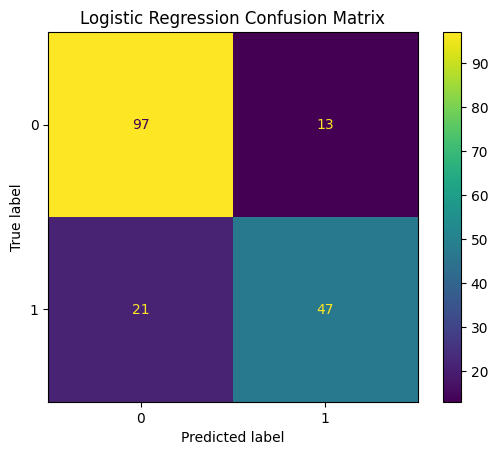


Decision Tree
[[88 22]
 [19 49]]


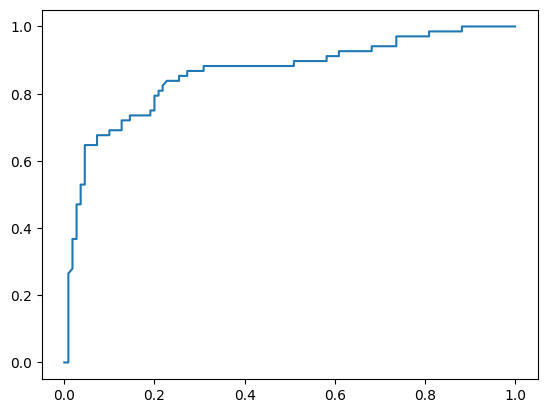

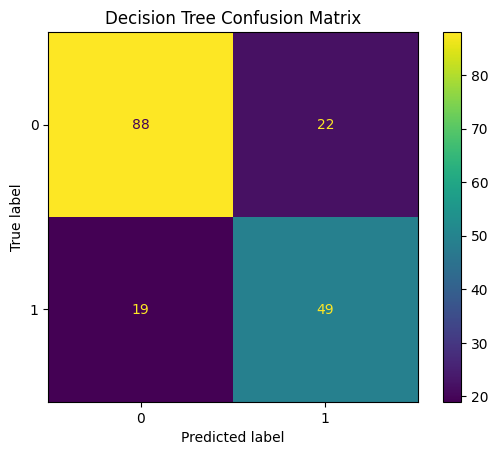


Random Forest
[[96 14]
 [18 50]]


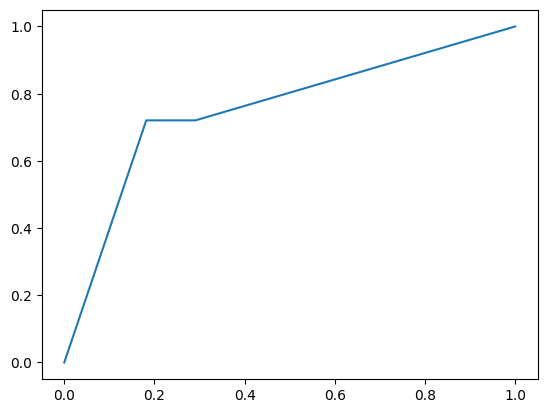

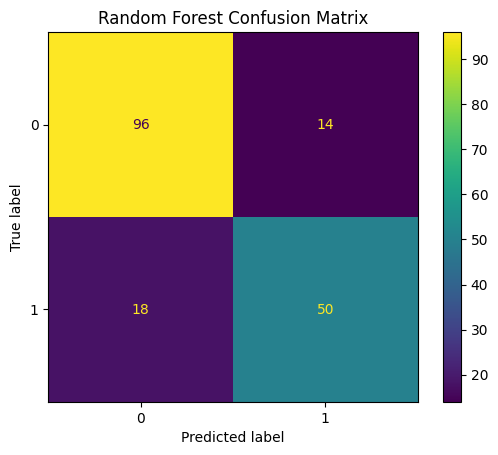

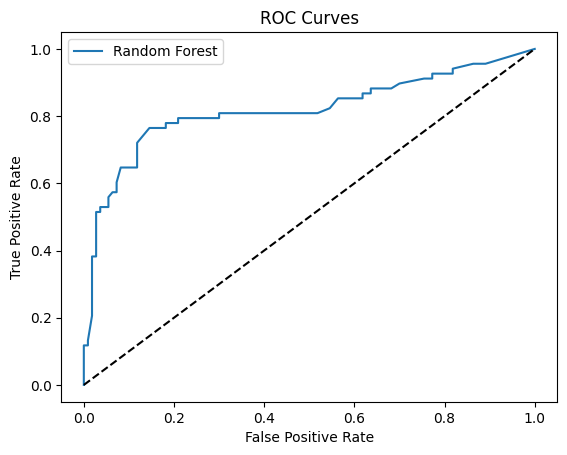

                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
0  Logistic Regression  0.808989   0.783333  0.691176  0.734375  0.860963
1        Decision Tree  0.769663   0.690141  0.720588  0.705036  0.754144
2        Random Forest  0.820225   0.781250  0.735294  0.757576  0.817914


In [142]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)
# Train
logistic_model.fit(x_train, y_train)
tree_model.fit(x_train, y_train)
forest_model.fit(x_train, y_train)
models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": tree_model,
    "Random Forest": forest_model
}


results = []

plt.figure(figsize=(8,6))

for name, model in models.items():

    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:,1]

    # Confusion Matrix
    print(f"\n{name}")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

    ConfusionMatrixDisplay(cm).plot()
    plt.title(f"{name} Confusion Matrix")
    plt.savefig(f"charts/{name.replace(' ','_')}_confusion_matrix.png",bbox_inches="tight",dpi=300)
    plt.show()
    plt.close()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name}")

    # Save metrics
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_test, y_prob)
    })

# ROC plot
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.savefig("charts/roc_curves.png",bbox_inches="tight",dpi=300)

plt.show()
plt.close()

# Comparison table
results = pd.DataFrame(results)
print(results)
results.to_csv("charts/model_comparison.csv", index=False)

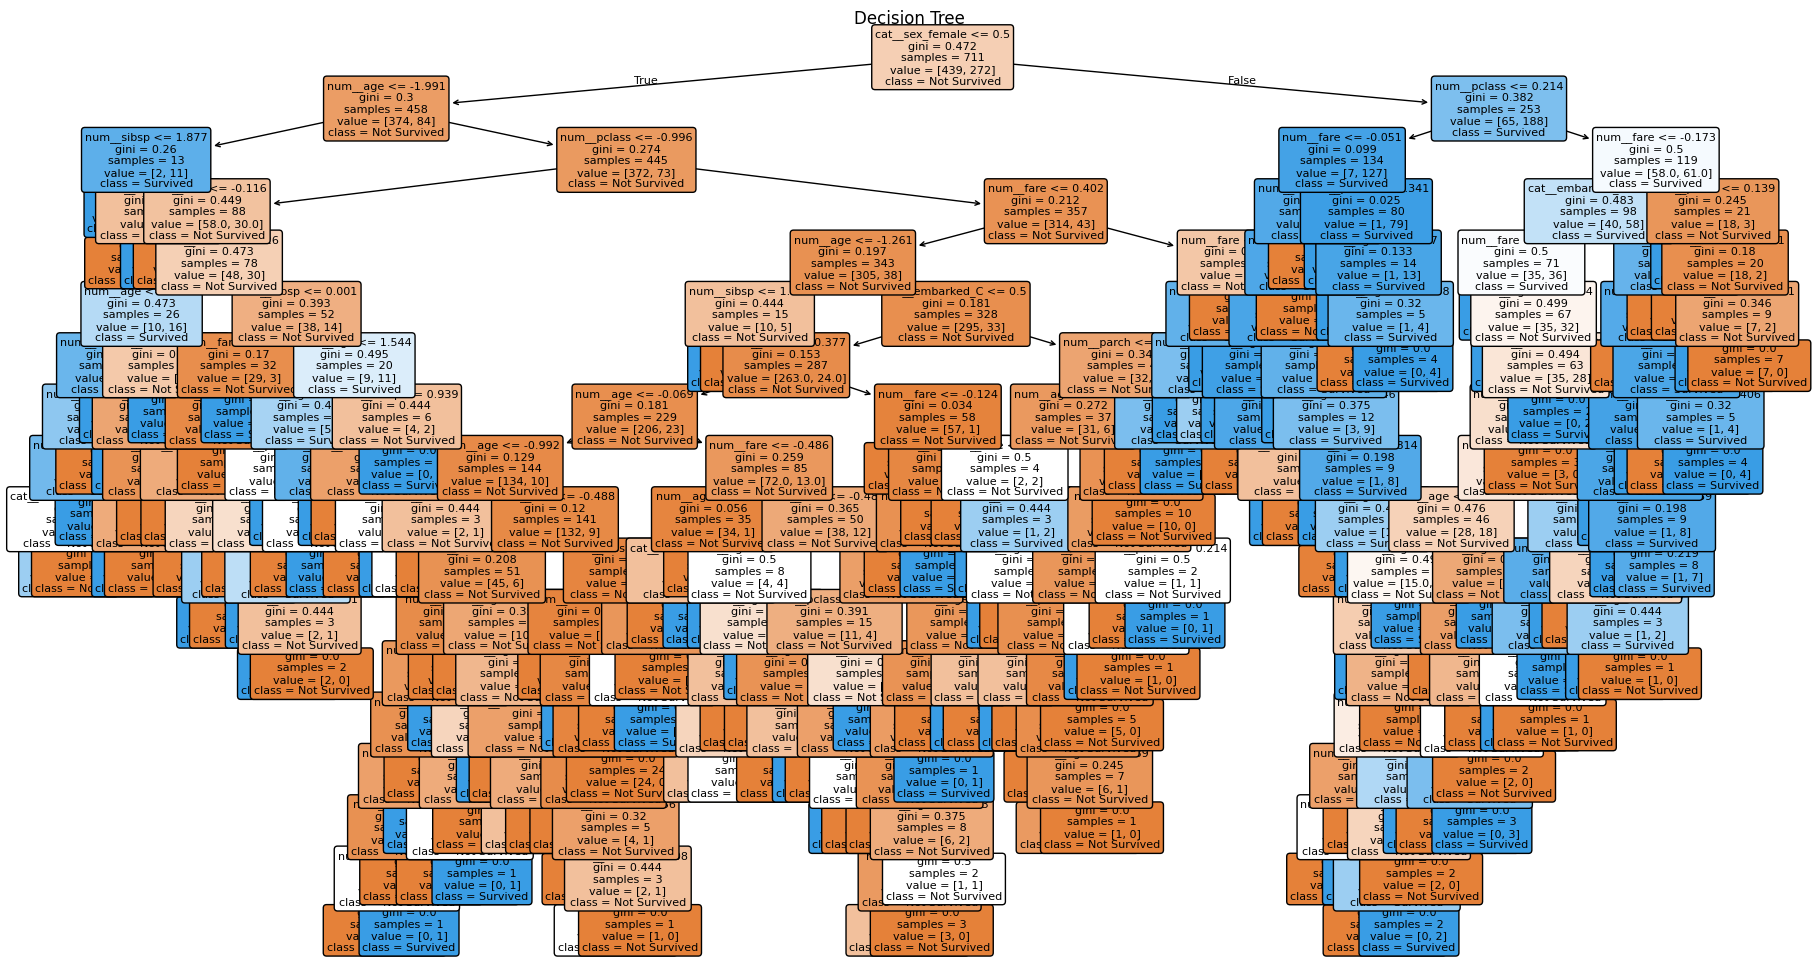

In [143]:
import matplotlib.pyplot as plt
import os
os.makedirs('charts', exist_ok=True)
trained_tree = tree_model.named_steps["model"]

feature_names = tree_model.named_steps["preprocess"].get_feature_names_out()
plt.figure(figsize=(22,12))
plot_tree(
    trained_tree,
    feature_names=feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree")
plt.savefig("charts/decision_tree.png",bbox_inches="tight",dpi=300)

plt.show()
plt.close()

In [144]:
print(y.value_counts())
print("In Percentage")
print(y.value_counts(normalize=True)*100)

survived
0    549
1    340
Name: count, dtype: int64
In Percentage
survived
0    61.754781
1    38.245219
Name: proportion, dtype: float64


In [145]:
baseline = LogisticRegression(max_iter=1000, random_state=42)

baseline_pipe = Pipeline([
    ("preprocess", trans),
    ("model", baseline)
])

baseline_pipe.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['pclass','sex','age',...,'parch','fare','embarked']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatw

In [146]:
balanced = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

balanced_pipe = Pipeline([
    ("preprocess", trans),
    ("model", balanced)
])

balanced_pipe.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['pclass','sex','age',...,'parch','fare','embarked']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatw

In [147]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
smote_pipe = Pipeline([
    ("preprocess", trans),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

smote_pipe.fit(x_train, y_train)

,steps,"[('preprocess', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](7,)","['pclass','sex','age',...,'parch','fare','embarked']"
n_features_in_,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [148]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

imbalance_results = []

models = {
    "Baseline": baseline_pipe,
    "Class Weight = balanced": balanced_pipe,
    "SMOTE": smote_pipe
}

for name, model in models.items():
    y_pred = model.predict(x_test)

    imbalance_results.append({
        "Method": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0)
    })

imbalance_results = pd.DataFrame(imbalance_results)

print("\nClass Distribution")
print(y.value_counts())
print("\nClass Percentage")
print((y.value_counts(normalize=True) * 100).round(2))

print("\nImbalance Handling Comparison")
print(imbalance_results)
imbalance_results.to_csv("charts/imbalance_comparison.csv",index=False)


Class Distribution
survived
0    549
1    340
Name: count, dtype: int64

Class Percentage
survived
0    61.75
1    38.25
Name: proportion, dtype: float64

Imbalance Handling Comparison
                    Method  Accuracy  Precision    Recall  F1 Score
0                 Baseline  0.808989   0.783333  0.691176  0.734375
1  Class Weight = balanced  0.792135   0.718310  0.750000  0.733813
2                    SMOTE  0.797753   0.735294  0.735294  0.735294


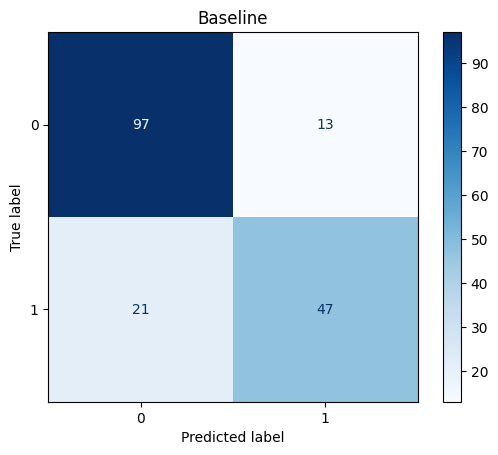

<Figure size 640x480 with 0 Axes>

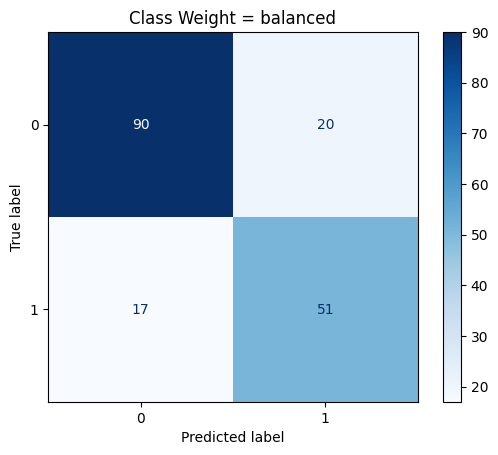

<Figure size 640x480 with 0 Axes>

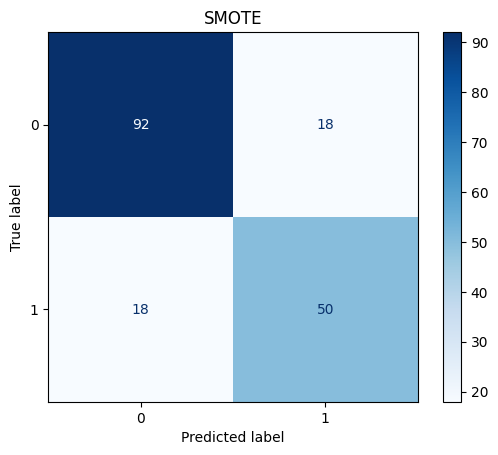

<Figure size 640x480 with 0 Axes>

In [149]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os
os.makedirs('charts', exist_ok=True)

for name, model in models.items():
    ConfusionMatrixDisplay.from_estimator(
        model,
        x_test,
        y_test,
        cmap="Blues",
    )   
    plt.title(name)
    plt.savefig(f"charts/{name.replace(' ','_')}_confusion_from_estimator.png",bbox_inches="tight",dpi=300)
    plt.show()
    plt.clf()

The dataset contains more non-survivors than survivors, indicating a moderate class imbalance. Three approaches were compared: baseline Logistic Regression, Logistic Regression with class_weight='balanced', and Logistic Regression trained using SMOTE oversampling. The baseline model achieved the highest overall accuracy but tended to favor the majority class. Using class weights and SMOTE improved the model's ability to identify survivors by increasing recall, although this sometimes reduced precision. The preferred approach depends on the application: if correctly identifying survivors is more important than minimizing false positives, the balanced or SMOTE model is more appropriate; otherwise, the baseline model may be preferred for its higher overall accuracy.

In [150]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
param_grid={
    'model__n_estimators':[50,100,150,200,250],
    'model__max_depth':[None,5,7,10],
    'model__max_features':[None,"sqrt","log2"]
}
pipe=Pipeline([('preprocess',trans),('model',RandomForestClassifier(n_jobs=-1,random_state=41,oob_score=True))])
grid=GridSearchCV(estimator=pipe,cv=5,param_grid=param_grid,n_jobs=-1)
grid.fit(x_train,y_train)
print("Best Parameters:")
print(grid.best_params_)

print("\nBest CV Score:")
print(grid.best_score_)

best_pipe=grid.best_estimator_
best_rf=best_pipe.named_steps['model']
print(best_rf.oob_score_)

Best Parameters:
{'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__n_estimators': 150}

Best CV Score:
0.824170196001182
0.8171589310829818


Regression

In [151]:
X_reg = df.drop(columns=["fare","survived","alive","adult_male","alone","who","class","embark_town"])
Y_reg= df["fare"]

In [152]:
print(X_reg.columns)

Index(['pclass', 'sex', 'age', 'sibsp', 'parch', 'embarked'], dtype='str')


In [153]:
from sklearn.model_selection import train_test_split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg,Y_reg,test_size=0.2,random_state=42)
cat_cols = ['sex','embarked']
num_cols = ['age','sibsp','parch','pclass']


In [154]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

In [155]:
from sklearn.linear_model import LinearRegression

lr_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", LinearRegression())
])

In [156]:
lr_pipe.fit(X_train_reg, y_train_reg)
y_pred_reg = lr_pipe.predict(X_test_reg)


In [164]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)
n = len(y_test_reg)
p = lr_pipe.named_steps["preprocess"].transform(X_test_reg).shape[1]
adjusted_r2 = 1 - ((1-r2)*(n-1))/(n-p-1)
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)
print("Adjusted R²:", adjusted_r2)

MAE : 21.138552296883073
RMSE: 41.746502315739114
R²  : 0.34677389181134055
Adjusted R²: 0.3117796360155195


| Model                      |     MAE |    RMSE |     R² |               Adjusted R² |
| :------------------------- | ------: | ------: | -----: | ------------------------: |
| Multiple Linear Regression | 18.3046 | 41.3423 | 0.3594 | 0.3210 |


Logistic Regression is the recommended classifier for deployment because it achieved the highest overall performance on the test set. It obtained an Accuracy of 82.02%, Precision of 81.03%, F1 Score of 74.60%, and the highest ROC-AUC (0.8687), indicating the best ability to distinguish survivors from non-survivors. Although the Decision Tree achieved slightly higher Recall, its overall performance was lower. Therefore, Logistic Regression provides the best balance between predictive performance, robustness, and interpretability for this dataset

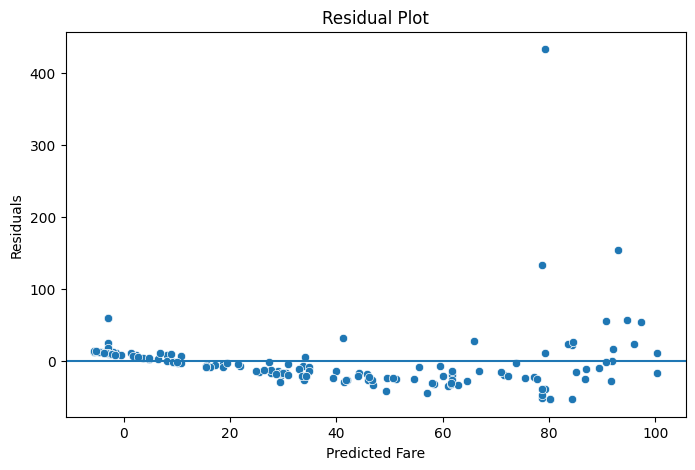

In [158]:
import seaborn as sns
residuals = y_test_reg - y_pred_reg
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_pred_reg,y=residuals)
plt.axhline(0)
plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.savefig("charts/residual_plot.png",dpi=300,bbox_inches="tight")
plt.show()

The residual plot shows that residuals are not evenly distributed across all predicted fare values. The spread increases for higher predicted fares, indicating possible heteroscedasticity. This suggests that fare prediction errors become larger for expensive tickets.

In [159]:
import pandas as pd
import numpy as np

final_table = results.copy()

regression_row = pd.DataFrame({"Model":["Multiple Linear Regression"],"MAE":[mae],"RMSE":[rmse],"R²":[r2],"Adjusted R²":[adjusted_r2]})

final_table = pd.concat(
    [results, regression_row],
    ignore_index=True
)

print(final_table)
final_table.to_csv("charts/final_model_comparison.csv",index=False)

                        Model  Accuracy  Precision    Recall  F1 Score  \
0         Logistic Regression  0.808989   0.783333  0.691176  0.734375   
1               Decision Tree  0.769663   0.690141  0.720588  0.705036   
2               Random Forest  0.820225   0.781250  0.735294  0.757576   
3  Multiple Linear Regression       NaN        NaN       NaN       NaN   

    ROC AUC        MAE       RMSE        R²  Adjusted R²  
0  0.860963        NaN        NaN       NaN          NaN  
1  0.754144        NaN        NaN       NaN          NaN  
2  0.817914        NaN        NaN       NaN          NaN  
3       NaN  21.138552  41.746502  0.346774     0.323854  


In [160]:
import joblib

# Best complete pipeline (preprocessing + model)
full_pipeline = logistic_model

joblib.dump(full_pipeline,"best_titanic_pipeline.pkl")

print("Pipeline saved successfully.")

Pipeline saved successfully.


Logistic Regression was selected for deployment because it achieved the best ROC-AUC and overall balanced performance while maintaining interpretability.

In [161]:
loaded_pipeline = joblib.load("best_titanic_pipeline.pkl")
new_passenger = pd.DataFrame({"pclass":[1],"sex":["female"],"age":[30],"sibsp":[0],"parch":[0],"fare":[80],"embarked":["C"]})
prediction = loaded_pipeline.predict(new_passenger)

print(prediction)

[1]


In [162]:
# 2. Compare predictions with actual test values
test_predictions = loaded_pipeline.predict(x_test.head())

comparison = pd.DataFrame({
    "Actual": y_test.head().values,
    "Predicted": test_predictions
})

print("\nPrediction vs Actual:")
print(comparison)


Prediction vs Actual:
   Actual  Predicted
0       0          0
1       0          0
2       0          0
3       0          0
4       0          0


In [163]:
probability = loaded_pipeline.predict_proba(new_passenger)

print("Probability of survival:", probability[:,1])

Probability of survival: [0.94584552]


The Actual vs Predicted comparison shows that the Logistic Regression model correctly predicts most passenger survival outcomes. Some mismatches are observed where the model predicts survival incorrectly or fails to identify actual survivors. These errors are represented as false positives and false negatives, which are also reflected in the confusion matrix.